In [11]:
import numpy as np
import glob
import lgdo.lh5 as lh5
import os, json
import copy
from pathlib import Path
import shutil
import glob
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pygama.pargen.utils import load_data
from legendmeta import LegendMetadata
from dbetto import Props, TextDB, AttrsDict
import pandas as pd
from tqdm.notebook import tqdm
import awkward as ak
import polars as pl

from helper_lib import *
from resolution_extraction import weighted_resolution_from_nested_dict as wres_full
from resolution_extraction import weighted_resolution_per_detector as wres_det
from resolution_extraction import weighted_value_per_det_type as wval_dtype
from resolution_extraction import weighted_resolution_per_detector_type as wres_dtype
from resolution_extraction import get_eres_per_detector
import resolution_extraction as rex

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
version = "v2.1.5"
base = f"/global/cfs/projectdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/{version}/"
scratch_folder = "/pscratch/sd/b/borrfran/sim-v1.1.0-20260401/"
# metadata2_path = os.environ["METADATA"]
metadata2_path = "/global/homes/b/borrfran/workspace/l200/legend-metadata"
config = Props.read_from(base+"/config.json", subst_pathvar=True)['setups']['l200']['paths']


meta = LegendMetadata(config['metadata'])
meta2 = LegendMetadata(metadata2_path)

timestamp = meta.dataprod.runinfo.p03.r000.phy.start_key

chmap = meta.channelmap(timestamp)
chmap_ak = ak.Array(chmap.group("system").geds.values())

DET_TYPES = ("BEGe", "COAX", "ICPC", "PPC")
DET_TYPE_MAP = {"B": "BEGe", "C": "COAX", "V": "ICPC", "P": "PPC"}

simulated_energies = list(range(200, 1100, 100))

datasets_outdir = "./v1/parquet/"
interaction = "axio-electric"
dictionaries_dir = "./v1/dictionaries"

could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fefc7bc9800>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fefc7bc9a80>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fefc7bca980>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fefc7bca7a0>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fefc7bed990>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fefc7beff60>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldat

# Popolate Parquet dataset from simulation

In [3]:
outdir_name = "axio-electric2"
job_base="electron_{tag}_hpge_bulk"

build_parquet_dataset(
    simulated_energies,
    scratch_folder=scratch_folder,
    job_base=job_base,
    outdir_name= outdir_name,
    overwrite=True,
)

  0%|          | 0/9 [00:00<?, ?it/s]

# Read Parquet dataset

In [3]:
rawid_by_det_type = Props.read_from(f'{dictionaries_dir}/rawid_by_det_type.yaml')

In [4]:
outdir_name = "axio-electric2"
lf = pl.scan_parquet(
    f"{datasets_outdir}/{outdir_name}",
    hive_partitioning=True
)

NameError: name 'outdir_name' is not defined

## Plot energy spectrum by detector type

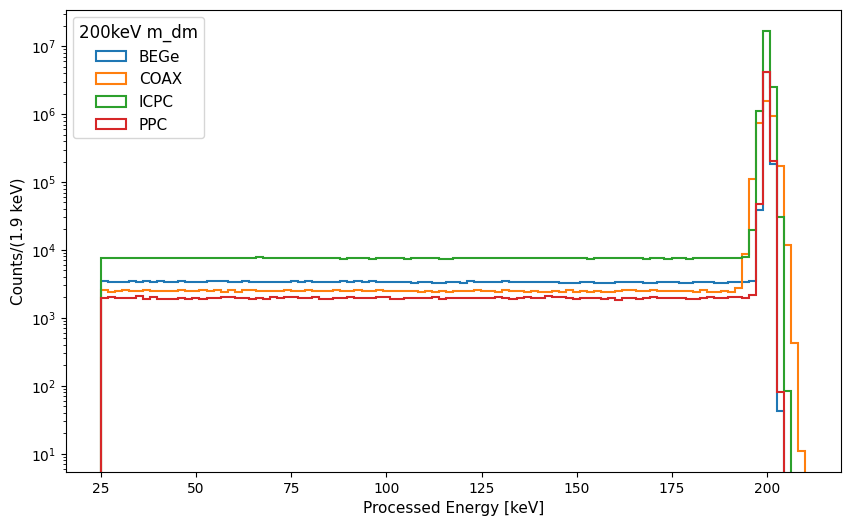

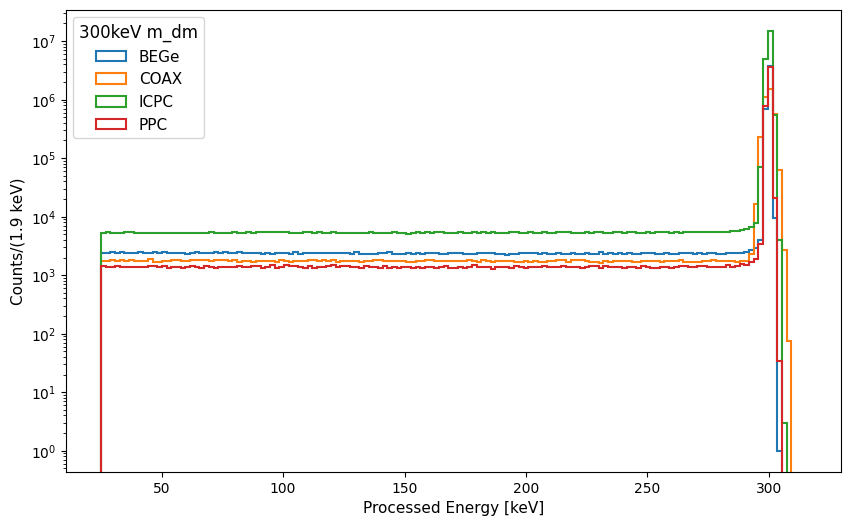

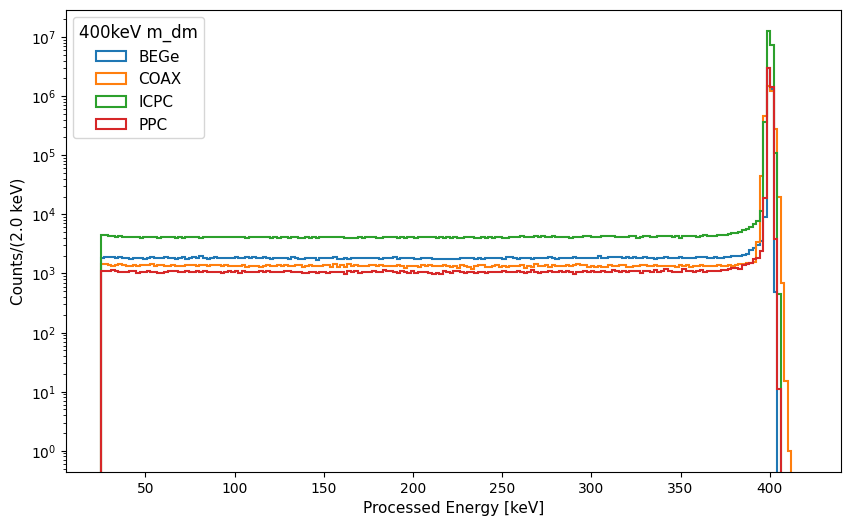

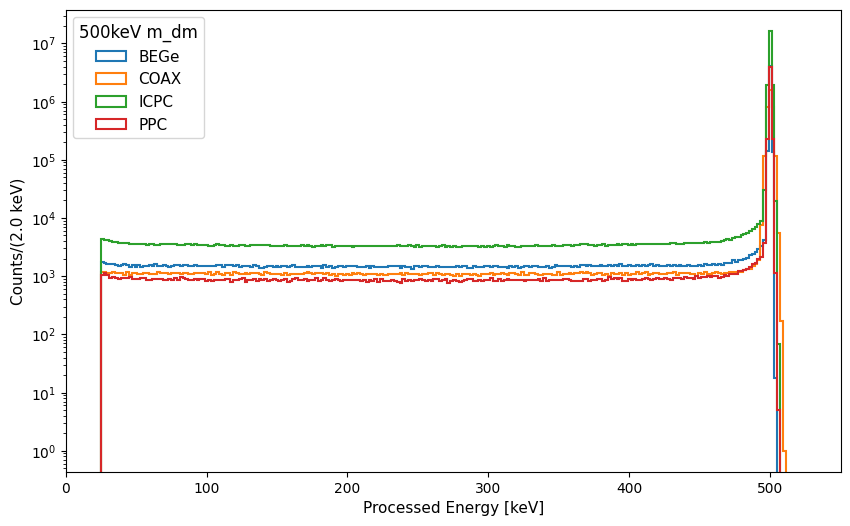

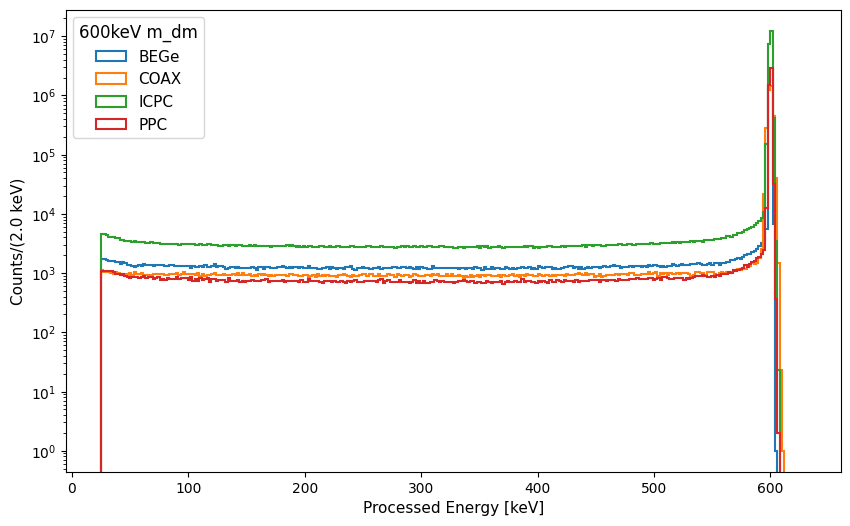

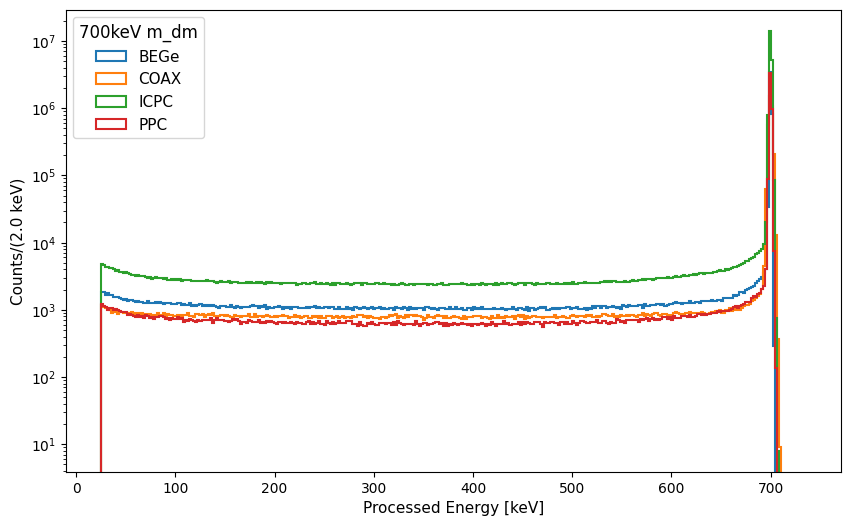

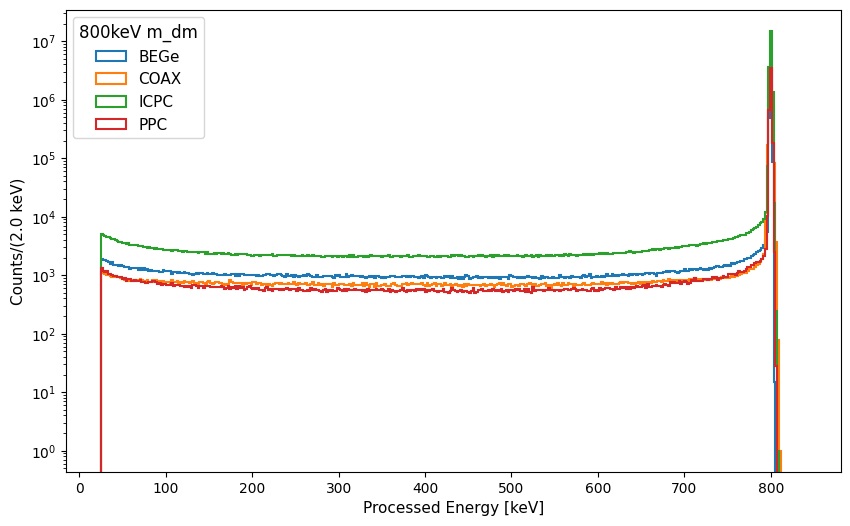

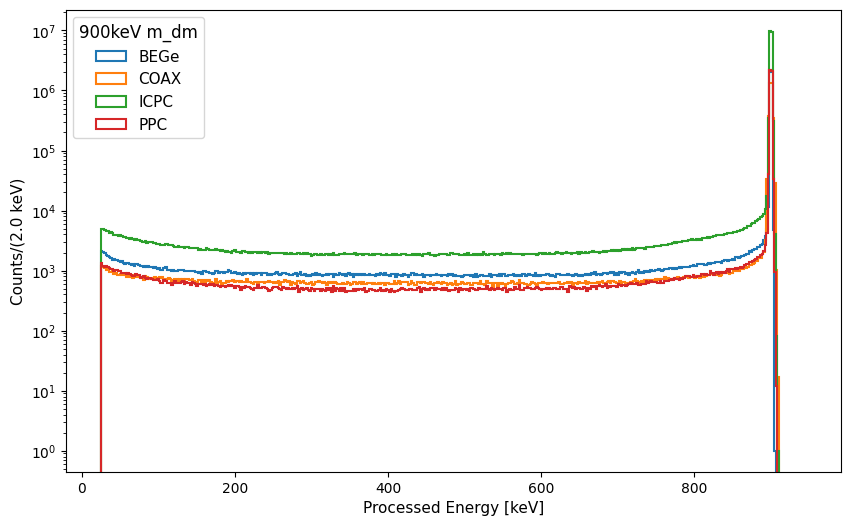

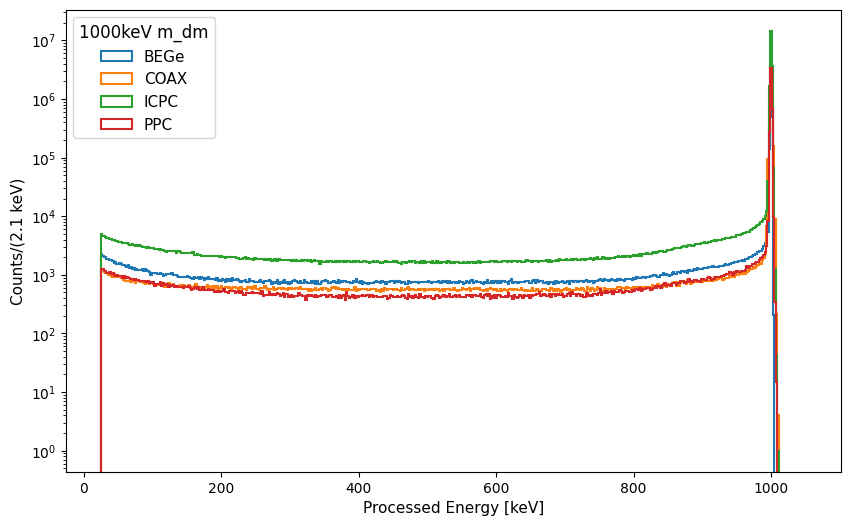

In [18]:
lw = 1.5
for ene in simulated_energies:
    
    plt.figure(figsize=(10, 6))
    bins = int(ene/2)

    _, bin_edges = np.histogram([], bins=bins, range=(25, ene*1.05))
    bin_width = bin_edges[1] - bin_edges[0]

    for det_type in DET_TYPES:
        filtered_df = (
            lf.filter(
                (pl.col("sim_e") == ene) &
                pl.col("rawid").is_in(rawid_by_det_type[det_type])
            )
            .select([
                "energy"
            ])
            .collect()
        )
        
        plt.hist(
            filtered_df['energy'], 
            bins=bin_edges, 
            label=det_type, 
            histtype="step", 
            linewidth=lw
        )
    
    plt.yscale("log")
    plt.legend(title=f"{ene}keV m_dm", title_fontsize=12, fontsize=11)
    plt.xlabel("Processed Energy [keV]", fontsize=11)
    plt.ylabel(f"Counts/({bin_width:.1f} keV)", fontsize=11)
    plt.savefig(f"./plots/{interaction}/det-type_energy-{ene}_{interaction}_LAr-cut.png", dpi=300)
    plt.show()


## Compute fully contained efficiency

In [52]:
eres_dict = Props.read_from(f"{dictionaries_dir}/eres_per_det_tot.yaml")

In [54]:
job_base="electron_{ene}keV_hpge_bulk"

ratio_dict = compute_efficiency_from_lazyframe(
    lf,
    eres_dict,
    simulated_energies,
    chmap,
    scratch_folder,
    job_base
)

  0%|          | 0/9 [00:00<?, ?it/s]

In [18]:
Props.write_to(f"{dictionaries_dir}/axio-effect_ratio-dict.yaml", ratio_dict)

In [ ]:
for ene in simulated_energies:
    y1 = []
    y2 = []
    x = []
    for ge in ratio_dict[ene]:
        y1.append(ratio_dict[ene][ge]['ratio_sigma'])
        y2.append(ratio_dict[ene][ge]['ratio_sigma_freq'])
        x.append(ge)


    plt.figure(figsize=(16, 7))
    plt.scatter(x, y1, marker = '.', label='bayesian')
    plt.scatter(x, y2, marker = '.', label='frequentist', alpha = 0.5)
    plt.xticks(ticks=range(len(x)), labels=x, rotation=90, ha='center')
    plt.ylabel(r"$\sigma_\epsilon$", fontsize = 16)
    # plt.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
    # ax.set_ylim(0.75, 1)
    plt.legend(title=f"{interaction} @ {ene}keV")
    # Padding sotto per non tagliare le etichette
    plt.tight_layout()
    # plt.savefig(f"./plots/{interaction}/FC-efficiency_{interaction}.png", dpi=500)
    plt.show()

    plt.figure(figsize=(16, 7))
    plt.scatter(x, np.array(y1)-np.array(y2), marker = '.', label='diff', alpha = 0.5)
    plt.xticks(ticks=range(len(x)), labels=x, rotation=90, ha='center')
    plt.ylabel(r"$\Delta \sigma_\epsilon$", fontsize = 16)
    plt.legend()
    # Padding sotto per non tagliare le etichette
    plt.legend(title=f"{interaction} @ {ene}keV")    
    # plt.savefig(f"./plots/{interaction}/FC-efficiency_{interaction}.png", dpi=500)
    plt.show()

        

In [14]:
ratio_dict_means = get_mean_fcc_det_type(
    ratio_dict, key = "ratio", 
    weight_key = "expo", 
    unc_key= "ratio_sigma",
    exclude_dets = ['C00ANG5', 'C00ANG3', 'C00ANG2', 'V05261A', 'B00002A', 'B00032C']
)

In [15]:
B = []
C = []
I = []
P = []

Bs = []
Cs = []
Is = []
Ps = []

for ene in ratio_dict_means.keys():

    B.append(ratio_dict_means[ene]['BEGe']['value'])
    I.append(ratio_dict_means[ene]['ICPC']['value'])
    C.append(ratio_dict_means[ene]['COAX']['value'])
    P.append(ratio_dict_means[ene]['PPC']['value'])
    
    Bs.append(ratio_dict_means[ene]['BEGe']['unc'])
    Is.append(ratio_dict_means[ene]['ICPC']['unc'])
    Cs.append(ratio_dict_means[ene]['COAX']['unc'])
    Ps.append(ratio_dict_means[ene]['PPC']['unc'])

B = np.array(B)
C = np.array(C)
I = np.array(I)
P = np.array(P)

Bs = np.array(Bs)
Cs = np.array(Cs)
Is = np.array(Is)
Ps = np.array(Ps)


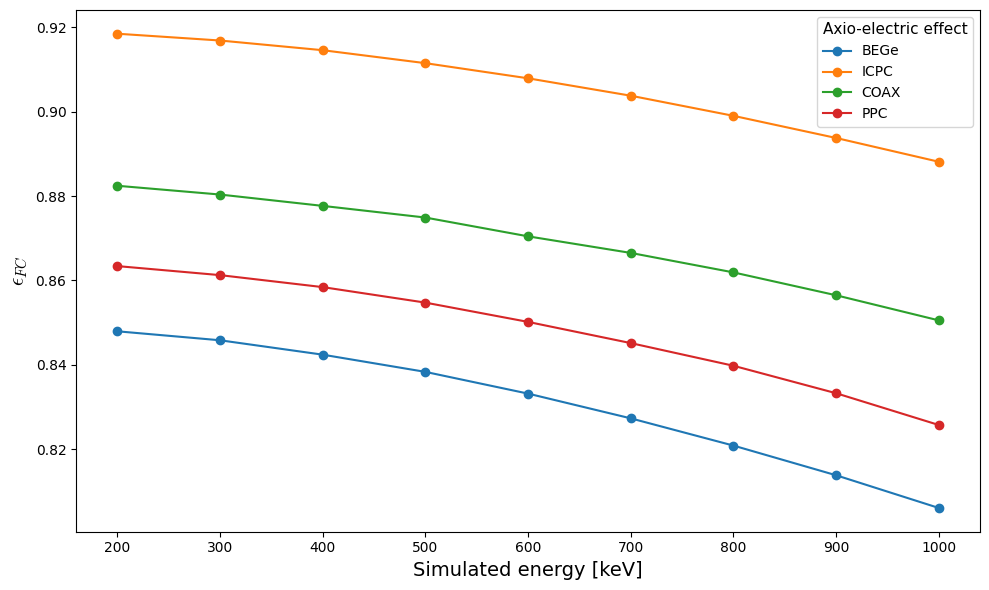

In [16]:
x = ratio_dict_means.keys()
plt.rcParams["mathtext.fontset"] = "cm"
plt.figure(figsize=(10,6))

plt.plot(x, B, marker = 'o', label = 'BEGe')
plt.plot(x, I, marker = 'o', label = 'ICPC')
plt.plot(x, C, marker = 'o', label = 'COAX')
plt.plot(x, P, marker = 'o', label = 'PPC')

plt.xlabel('Simulated energy [keV]', fontsize = 14)
plt.ylabel(r"$\epsilon_{FC}$", fontsize = 15)
plt.legend(title='Axio-electric effect', 
           title_fontsize=11, loc = "upper right", 
           alignment="left")
plt.tight_layout()
plt.savefig(f'./plots/{interaction}/FC-eff_det-type_{interaction}.png', dpi = 500)
plt.show()

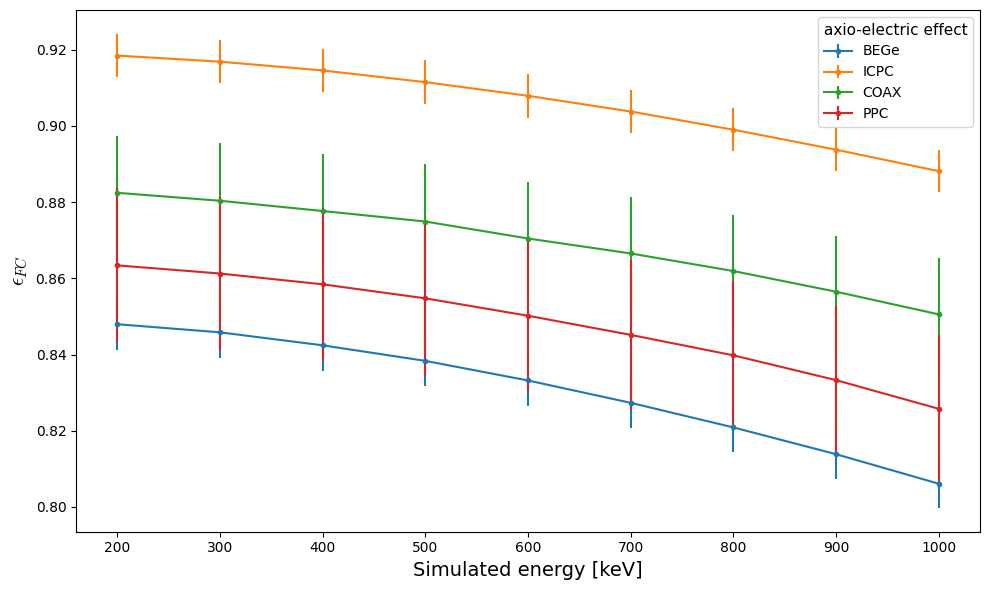

In [17]:
x = ratio_dict_means.keys()
plt.rcParams["mathtext.fontset"] = "cm"
plt.figure(figsize=(10,6))

plt.errorbar(x, B, yerr = Bs, marker = '.', label = 'BEGe')
plt.errorbar(x, I, yerr = Is, marker = '.', label = 'ICPC')
plt.errorbar(x, C, yerr = Cs, marker = '.', label = 'COAX')
plt.errorbar(x, P, yerr = Ps, marker = '.', label = 'PPC')

plt.xlabel('Simulated energy [keV]', fontsize = 14)
plt.ylabel(r"$\epsilon_{FC}$", fontsize = 15)
plt.legend(title=f'{interaction} effect', 
           title_fontsize=11, loc = "upper right", 
           alignment="left")
plt.tight_layout()
plt.savefig(f'./plots/{interaction}/FC-eff_det-type_{interaction}_errorbar.png', dpi = 500)
plt.show()

  0%|          | 0/9 [00:00<?, ?it/s]

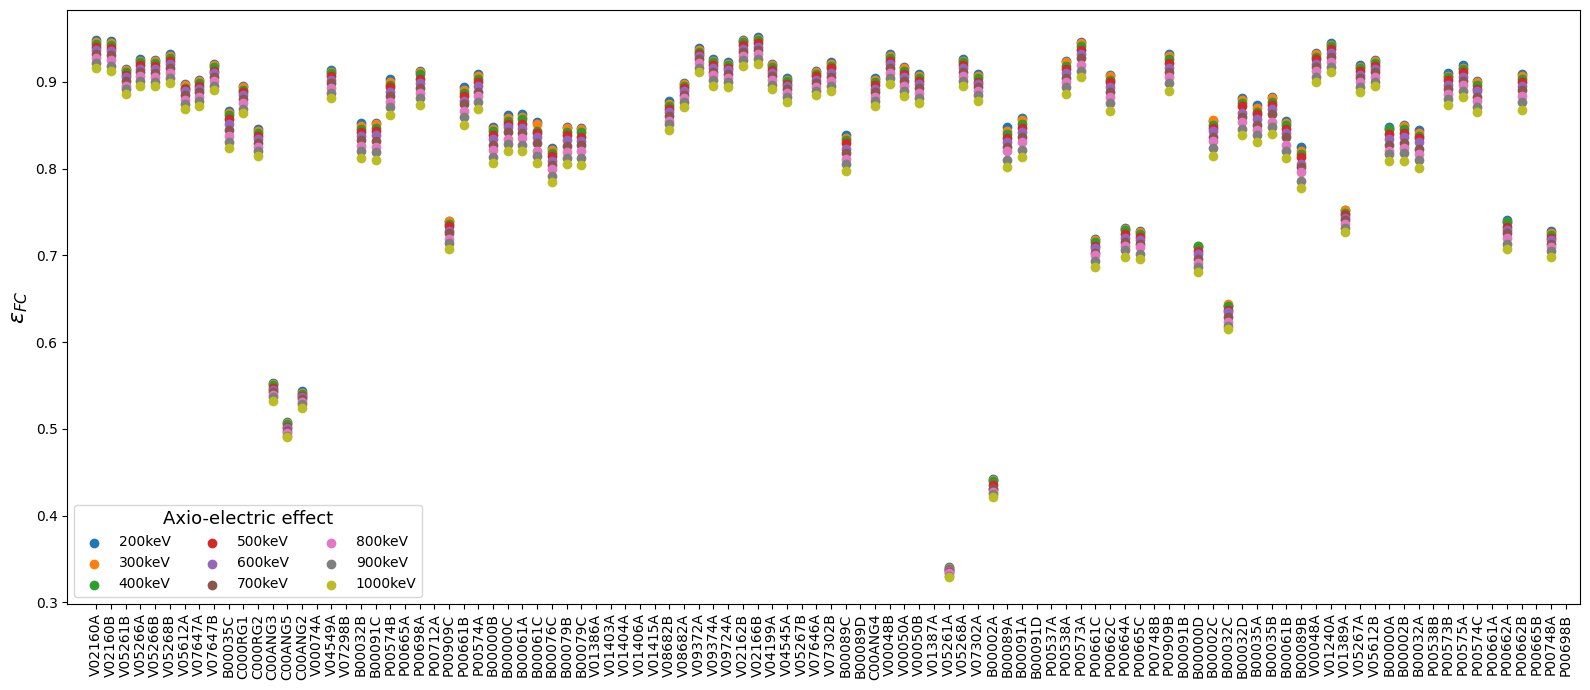

In [13]:
ges_sorted = chmap_ak.name

values_dict = {}

fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

for ene in tqdm(simulated_energies):
    
    keys, values = get_values_sorted(ratio_dict[ene], ges_sorted)
    tag = f'{ene}keV'
    ax.scatter(keys, values, marker = 'o', label=tag)


plt.xticks(ticks=range(len(keys)), labels=keys, rotation=90, ha='center')

ax.set_ylabel(r"$\epsilon_{FC}$", fontsize = 16)
ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
# ax.set_ylim(0.75, 1)
plt.legend(ncol = 3, title='Axio-electric effect', title_fontsize=13)

plt.tight_layout()
plt.savefig(f"./plots/{interaction}/FC-efficiency_{interaction}.png", dpi=500)
plt.show()


## Statistical uncertainty study

  0%|          | 0/9 [00:00<?, ?it/s]

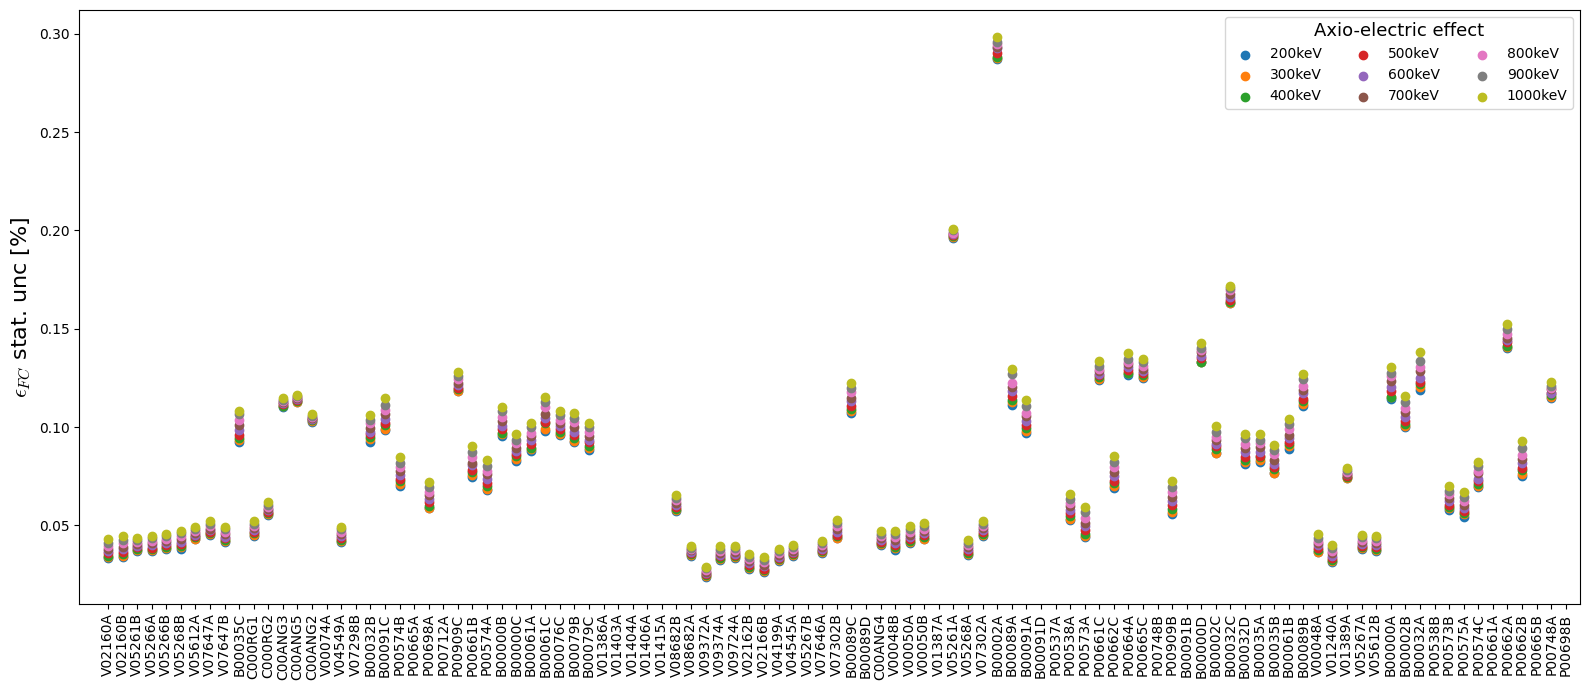

In [39]:
ges_sorted = chmap_ak.name

values_dict = {}

fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

for ene in tqdm(simulated_energies):
    
    keys, ratio = get_values_sorted(ratio_dict[ene], ges_sorted, key = 'ratio')
    keys, sigma = get_values_sorted(ratio_dict[ene], ges_sorted, key = 'ratio_sigma')
    tag = f'{ene}keV'
    ax.scatter(keys, np.array(sigma)/np.array(ratio)*100, marker = 'o', label=tag)


plt.xticks(ticks=range(len(keys)), labels=keys, rotation=90, ha='center')

plt.ylabel(r"$\epsilon_{FC}$ stat. unc [%]", fontsize = 16)
ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
# ax.set_ylim(0.75, 1)
plt.legend(ncol = 3, title='Axio-electric effect', title_fontsize=13)

plt.tight_layout()
plt.savefig(f"./plots/{interaction}/FC-stat-unc_{interaction}.png", dpi=500)
plt.show()

In [25]:
unc_list = []
unc_key = 'ratio_sigma'
# unc_key = 'ratio_syst_fwhm'
ene_sim = 1000
for key in ratio_dict[ene_sim]:
    if ratio_dict[ene_sim][key][unc_key] > 0.0015:
        print(key)
    if ratio_dict[ene_sim][key][unc_key] == 0 :
        unc_list.append(np.nan)
        continue
    unc_list.append(ratio_dict[ene_sim][key][unc_key]/ratio_dict[ene_sim][key]['ratio'])

B00035C
B00091C
B00000B
B00061C
B00089C
B00002A
B00089A
B00091A
B00000D
B00032C
B00089B
B00000A
B00002B
B00032A
P00662A


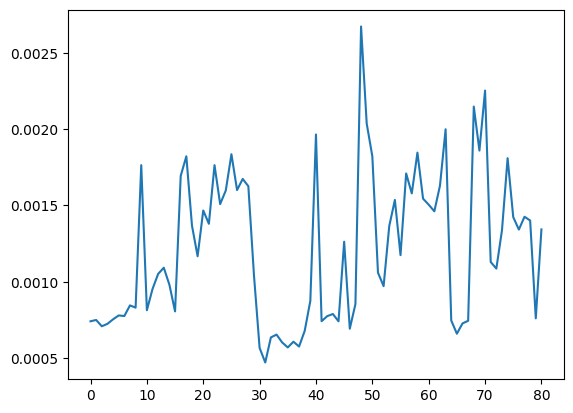

In [26]:
plt.plot(range(len(ratio_dict[ene_sim].keys())), unc_list)